In [1]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter


In [2]:
fname_in="../OUTPUTS/avg_eqpac30_eqpatch_sw.nc"
ds_in=xr.open_dataset(fname_in)
u=ds_in["u"]
v=ds_in["v"]
h=ds_in["p"]
lon=ds_in["lon_p"];lat=ds_in["lat_p"]
u_h=u.interp(x_u=h.x_p,y_u=h.y_p)
v_h=v.interp(x_v=h.x_p,y_v=h.y_p)
lon_2d,lat_2d=np.meshgrid(lon,lat)

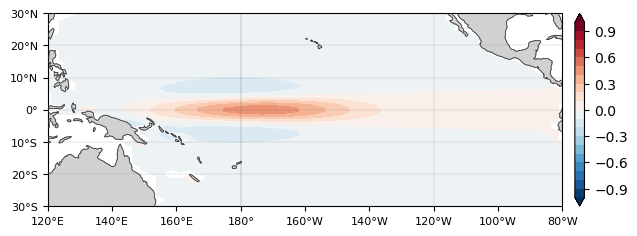

In [3]:
data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 5),
    subplot_kw={"projection": map_crs},
)
levels=np.linspace(-1,1,21)
extent=[120,280,-30,30]

axes.set_extent(extent, crs=data_crs)
axes.add_feature(cfeature.LAND,facecolor="0.82", edgecolor="0.45",linewidth=0.4,zorder=2,)
axes.coastlines(resolution="110m", linewidth=0.6, color="0.25", zorder=3)
axes.gridlines(draw_labels=False,linewidth=0.3,color="0.4",alpha=0.4,linestyle="-",)
lon_step = 20.0
lat_step = 10.0
lon_ticks = np.arange(
    np.ceil(extent[0] / lon_step) * lon_step,
    extent[1] + lon_step,
    lon_step,
)
lat_ticks = np.arange(
    np.ceil(extent[2] / lat_step) * lat_step,
    extent[3] + lat_step,
    lat_step,
)
axes.set_xticks(lon_ticks, crs=data_crs)
axes.set_yticks(lat_ticks, crs=data_crs)
axes.xaxis.set_major_formatter(LongitudeFormatter())
axes.yaxis.set_major_formatter(LatitudeFormatter())
axes.tick_params(labelsize=8)
contour_kwargs = {"transform": data_crs}

contour = axes.contourf(
    lon_2d,
    lat_2d,
    h[0,0,:,:],
    levels=levels,
    cmap="RdBu_r",
    extend="both",
    zorder=1,
    **contour_kwargs,
)
cbar_ssta = fig.colorbar(contour, ax=axes, orientation="vertical", pad=0.02,shrink=0.5)



[108, 302, -30, 30]


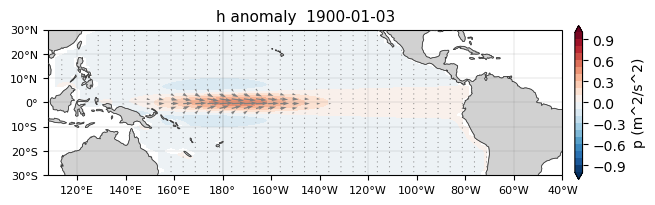

In [ ]:
data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 4),
    subplot_kw={"projection": map_crs},
)
h_levels=np.linspace(-1,1,21)
extent=[108,302,-30,30]
print(extent)
def decorate_axis(ax) -> None:
    ax.set_extent(extent, crs=data_crs)
    ax.add_feature(
        cfeature.LAND,
        facecolor="0.82",
        edgecolor="0.45",
        linewidth=0.4,
        zorder=2,
    )
    ax.coastlines(resolution="110m", linewidth=0.6, color="0.25", zorder=3)
    ax.gridlines(
        draw_labels=False,
        linewidth=0.3,
        color="0.4",
        alpha=0.4,
        linestyle="-",
    )
    lon_step = 20.0
    lat_step = 10.0
    lon_ticks = np.arange(
        np.ceil(extent[0] / lon_step) * lon_step,
        extent[1] + lon_step,
        lon_step,
    )
    lat_ticks = np.arange(
        np.ceil(extent[2] / lat_step) * lat_step,
        extent[3] + lat_step,
        lat_step,
    )
    ax.set_xticks(lon_ticks, crs=data_crs)
    ax.set_yticks(lat_ticks, crs=data_crs)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=8)

def draw_panel(ax, values,vx,vy, levels, cmap, title):
    contour_kwargs = {"transform": data_crs} 
    contour = ax.contourf(
        lon_2d,
        lat_2d,
        values,
        levels=levels,
        cmap=cmap,
        extend="both",
        zorder=1,
        **contour_kwargs,
    )
    vskip_x=4;vskip_y=2
    vector=ax.quiver(lon_2d[0::vskip_y,0::vskip_y],lat_2d[0::vskip_y,0::vskip_y],
                     vx[0::vskip_y,0::vskip_y],vy[0::vskip_y,0::vskip_y],color="grey",zorder=2,
                     transform=data_crs,scale=0.05,angles='xy', scale_units='xy')
    decorate_axis(ax)
    ax.set_title(title, fontsize=11)
    return contour,vector
def cut_frame(field: xr.DataArray, frame_index: int):
    values = field.isel(time=frame_index).values
    return values

def draw(frame_index: int):
    axes.clear()

    date_label = np.datetime_as_string(h.time.values[frame_index], unit="D")
    draw_panel(
        axes,
        cut_frame(h[:,0,:,:], frame_index),
        cut_frame(u_h[:,0,:,:], frame_index),
        cut_frame(v_h[:,0,:,:], frame_index),
        levels,
        "RdBu_r",
        f"h anomaly  {date_label}",
    )
    return []

first_h,vector= draw_panel(
    axes,
    cut_frame(h[:,0,:,:], 0),
    cut_frame(u_h[:,0,:,:], 0),
    cut_frame(v_h[:,0,:,:], 0),
    h_levels,
    "RdBu_r",
    f"SST anomaly",
)
cbar_h = fig.colorbar(first_h, ax=axes, orientation="vertical", pad=0.02,shrink=0.5)
cbar_h.set_label("p (m^2/s^2)")
animation = FuncAnimation(
    fig,
    draw,
    frames=h.sizes["time"],
    interval=60,
    blit=False,
)
output_path="anim_uvh_eqpac30_eqpatch.gif";fps=3
animation.save(output_path, writer=PillowWriter(fps=fps))
